# 1. Configuración de Entorno & GPU (Hardware)


**Objetivo del análisis exploratorio**

El presente análisis exploratorio de datos (EDA) tiene como objetivo caracterizar la estructura espacial, espectral y temporal del conjunto de datos PASTIS utilizado como referencia para el desarrollo del proyecto. El análisis busca identificar la calidad de los datos, posibles valores faltantes o atípicos, distribución y desbalance de las clases, relaciones entre bandas espectrales, comportamiento temporal de los cultivos y características relevantes para el posterior entrenamiento de modelos de segmentación semántica.

Este análisis constituye una etapa previa al desarrollo y adaptación del modelo hacia el objetivo final del proyecto: la segmentación de parcelas agrícolas utilizando imágenes satelitales correspondientes al territorio mexicano. Por esta razón, además de comprender PASTIS, se busca identificar qué características, transformaciones y estrategias de preprocesamiento deberán considerarse posteriormente al trabajar con un conjunto de datos mexicano.

In [ ]:
import torch
import tensorflow as tf

print("--- Verificación de Hardware ---")

# 1. Configuración de PyTorch
has_torch_gpu = torch.cuda.is_available()
if has_torch_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    device = torch.device("cuda")
    print(f"✅ PyTorch detectó GPU: {gpu_name} ({gpu_memory:.2f} GB VRAM)")
else:
    device = torch.device("cpu")
    print("⚠️ PyTorch no detectó GPU. Ejecutando en CPU.")

# 2. Configuración de TensorFlow
gpus_tf = tf.config.list_physical_devices('GPU')
if gpus_tf:
    print(f"✅ TensorFlow detectó {len(gpus_tf)} GPU(s): {gpus_tf[0].name}")
else:
    print("⚠️ TensorFlow no detectó GPU.")

# Activar la asignación dinámica de memoria en TF para evitar saturar VRAM
for gpu in gpus_tf:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

--- Verificación de Hardware ---
✅ PyTorch detectó GPU: Tesla T4 (15.64 GB VRAM)
✅ TensorFlow detectó 1 GPU(s): /physical_device:GPU:0


# 2. Estructura de Directorios & Inventario del Dataset

In [ ]:
import kagglehub
import numpy as np
import os

# Descargar el dataset
path = kagglehub.dataset_download("a01634782/pastis")

print("Dataset descargado en:", path)

# Ver archivos
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".npy"):
            print(os.path.join(root, file))

Dataset descargado en: /root/.cache/kagglehub/datasets/a01634782/pastis/versions/1
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/ParcelIDs_30661.npy
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/ParcelIDs_40031.npy
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/ParcelIDs_20479.npy
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/ParcelIDs_20230.npy
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/ParcelIDs_20643.npy
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/TARGET_40533.npy
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/ParcelIDs_10300.npy
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/TARGET_40186.npy
/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1/PASTIS/ANNOTATIONS/TARGET_40198.npy
/root/.cache/kagglehub/datasets/a01

In [ ]:
import os
import pandas as pd

def resumen_directorio(ruta_base):
    conteo_archivos = {}
    peso_total = 0

    print(f"📁 **Estructura del Dataset en:** `{ruta_base}`\n")
    print("-" * 60)

    for root, dirs, files in os.walk(ruta_base):
        rel_path = os.path.relpath(root, ruta_base)
        if rel_path == ".":
            rel_path = "Raíz"

        num_archivos = len(files)
        peso_carpeta = sum(os.path.getsize(os.path.join(root, f)) for f in files) / (1024 ** 2) # MB
        peso_total += peso_carpeta

        # Conteo por extensión
        extensiones = {}
        for f in files:
            ext = os.path.splitext(f)[1] or 'sin_extension'
            extensiones[ext] = extensiones.get(ext, 0) + 1

        detalles_ext = ", ".join([f"{count} {ext}" for ext, count in extensiones.items()])
        print(f"📂 {rel_path}/")
        print(f"   └── Archivos: {num_archivos} ({detalles_ext}) | Peso: {peso_carpeta:.2f} MB")

    print("-" * 60)
    print(f"💾 **Peso total descargado en disco:** {peso_total / 1024:.2f} GB")

# Ejecutar inspección
resumen_directorio(path)

📁 **Estructura del Dataset en:** `/root/.cache/kagglehub/datasets/a01634782/pastis/versions/1`

------------------------------------------------------------
📂 Raíz/
   └── Archivos: 0 () | Peso: 0.00 MB
📂 PASTIS/
   └── Archivos: 2 (1 .json, 1 .geojson) | Peso: 7.04 MB
📂 PASTIS/ANNOTATIONS/
   └── Archivos: 4866 (4866 .npy) | Peso: 267.59 MB
📂 PASTIS/DATA_S2/
   └── Archivos: 2468 (2468 .npy) | Peso: 36495.93 MB
📂 PASTIS/INSTANCE_ANNOTATIONS/
   └── Archivos: 7299 (7299 .npy) | Peso: 913.27 MB
------------------------------------------------------------
💾 **Peso total descargado en disco:** 36.80 GB


**Interpretación**

El conjunto de datos presenta una estructura multimodal compuesta principalmente por series temporales de imágenes Sentinel-2, anotaciones semánticas e información asociada a las instancias o parcelas agrícolas. El volumen total descargado es de aproximadamente 36.8 GB, lo cual confirma que el procesamiento completo requiere estrategias que consideren tanto el uso de memoria como el tiempo de ejecución.

Esta característica resulta particularmente relevante para las etapas posteriores del proyecto, ya que el procesamiento de imágenes satelitales de México podría involucrar volúmenes de información similares o superiores. Por ello, será necesario diseñar un pipeline capaz de procesar los datos por lotes y evitar la carga simultánea del conjunto completo en memoria.

# 3. Inspección de Tensores y Capas del Target

In [ ]:
import re

# Buscar pares S2 y TARGET en la ruta descargada
s2_dict, target_dict = {}, {}

for root, dirs, files in os.walk(path):
    for file in files:
        full_path = os.path.join(root, file)

        m_s2 = re.search(r"S2_(\d+)\.npy$", file)
        if m_s2:
            s2_dict[int(m_s2.group(1))] = full_path

        m_tg = re.search(r"TARGET_(\d+)\.npy$", file)
        if m_tg:
            target_dict[int(m_tg.group(1))] = full_path

ids_comunes = sorted(list(set(s2_dict.keys()) & set(target_dict.keys())))
print(f"🔍 Total de parches emparejados (S2 + TARGET): {len(ids_comunes)}")

# Inspección del primer parche disponible
if ids_comunes:
    sample_id = ids_comunes[0]
    s2_sample = np.load(s2_dict[sample_id])
    tg_sample = np.load(target_dict[sample_id])

    print("\n--- Estructura del Parche de Prueba ---")
    print(f"ID del Parche: {sample_id}")
    print(f"Dimensiones S2 (T, C, H, W): {s2_sample.shape}")
    print(f"Dimensiones TARGET (H, W) o (T_labels, H, W): {tg_sample.shape}")
    print(f"Tipo de datos S2: {s2_sample.dtype} | Min: {s2_sample.min()} | Max: {s2_sample.max()}")

    print("\n--- Inspección de las capas del TARGET ---")
    print("Shape TARGET:", tg_sample.shape)
    print("Capa 0 - valores únicos (clases semánticas):", np.unique(tg_sample[0]))
    print("Capa 1 - número de IDs únicos:", len(np.unique(tg_sample[1])))
    print("Capa 2 - valores únicos:", np.unique(tg_sample[2]))


# ============================================================
# MUESTRA EXPLORATORIA REPRODUCIBLE
# ============================================================

# Semilla para garantizar reproducibilidad
np.random.seed(42)

# Muestra utilizada únicamente en análisis exploratorios costosos
num_muestra = min(40, len(ids_comunes))

ids_muestra = np.random.choice(
    ids_comunes,
    size=num_muestra,
    replace=False
)

print(f"\nMuestra exploratoria reproducible: {len(ids_muestra)} parches")

🔍 Total de parches emparejados (S2 + TARGET): 2433

--- Estructura del Parche de Prueba ---
ID del Parche: 10000
Dimensiones S2 (T, C, H, W): (43, 10, 128, 128)
Dimensiones TARGET (H, W) o (T_labels, H, W): (3, 128, 128)
Tipo de datos S2: int16 | Min: -1338 | Max: 13756

--- Inspección de las capas del TARGET ---
Shape TARGET: (3, 128, 128)
Capa 0 - valores únicos (clases semánticas): [ 0  1  2  3  4  6 12 13 19]
Capa 1 - número de IDs únicos: 117
Capa 2 - valores únicos: [ 0  1  2  3  6 10 11 12 31 33 49 57 61 63 76 84 85 89]

Muestra exploratoria reproducible: 40 parches


**Interpretación de la estructura de los datos**

Cada muestra Sentinel-2 presenta una estructura (T, C, H, W), donde T corresponde al número de observaciones temporales, C=10 a las bandas espectrales y H=W=128 a las dimensiones espaciales originales.

El TARGET contiene tres capas diferentes, por lo que sus valores no deben interpretarse conjuntamente como clases. Para la segmentación semántica, la variable objetivo principal corresponde a la capa 0, que contiene la clase asignada a cada píxel. La capa 1 contiene identificadores de instancia que permiten distinguir regiones o parcelas dentro de cada patch y estudiar características como su geometría y tamaño. Estos identificadores se analizan a nivel de patch, sin asumir que sean globalmente únicos entre todas las muestras. La función exacta de la tercera capa deberá mantenerse conforme a la documentación oficial del dataset antes de incorporarla al pipeline.

Esta estructura confirma que el problema no corresponde a una clasificación convencional de imágenes, sino a una tarea supervisada de segmentación semántica multiclase a nivel de píxel.

# 4. Visualización Espacio-Temporal

--- Análisis de Capas del TARGET ---
Clases semánticas presentes (Capa 0): [ 0  1  2  3  4  6 12 13 19]
Número de parcelas independientes (Capa 1): 117


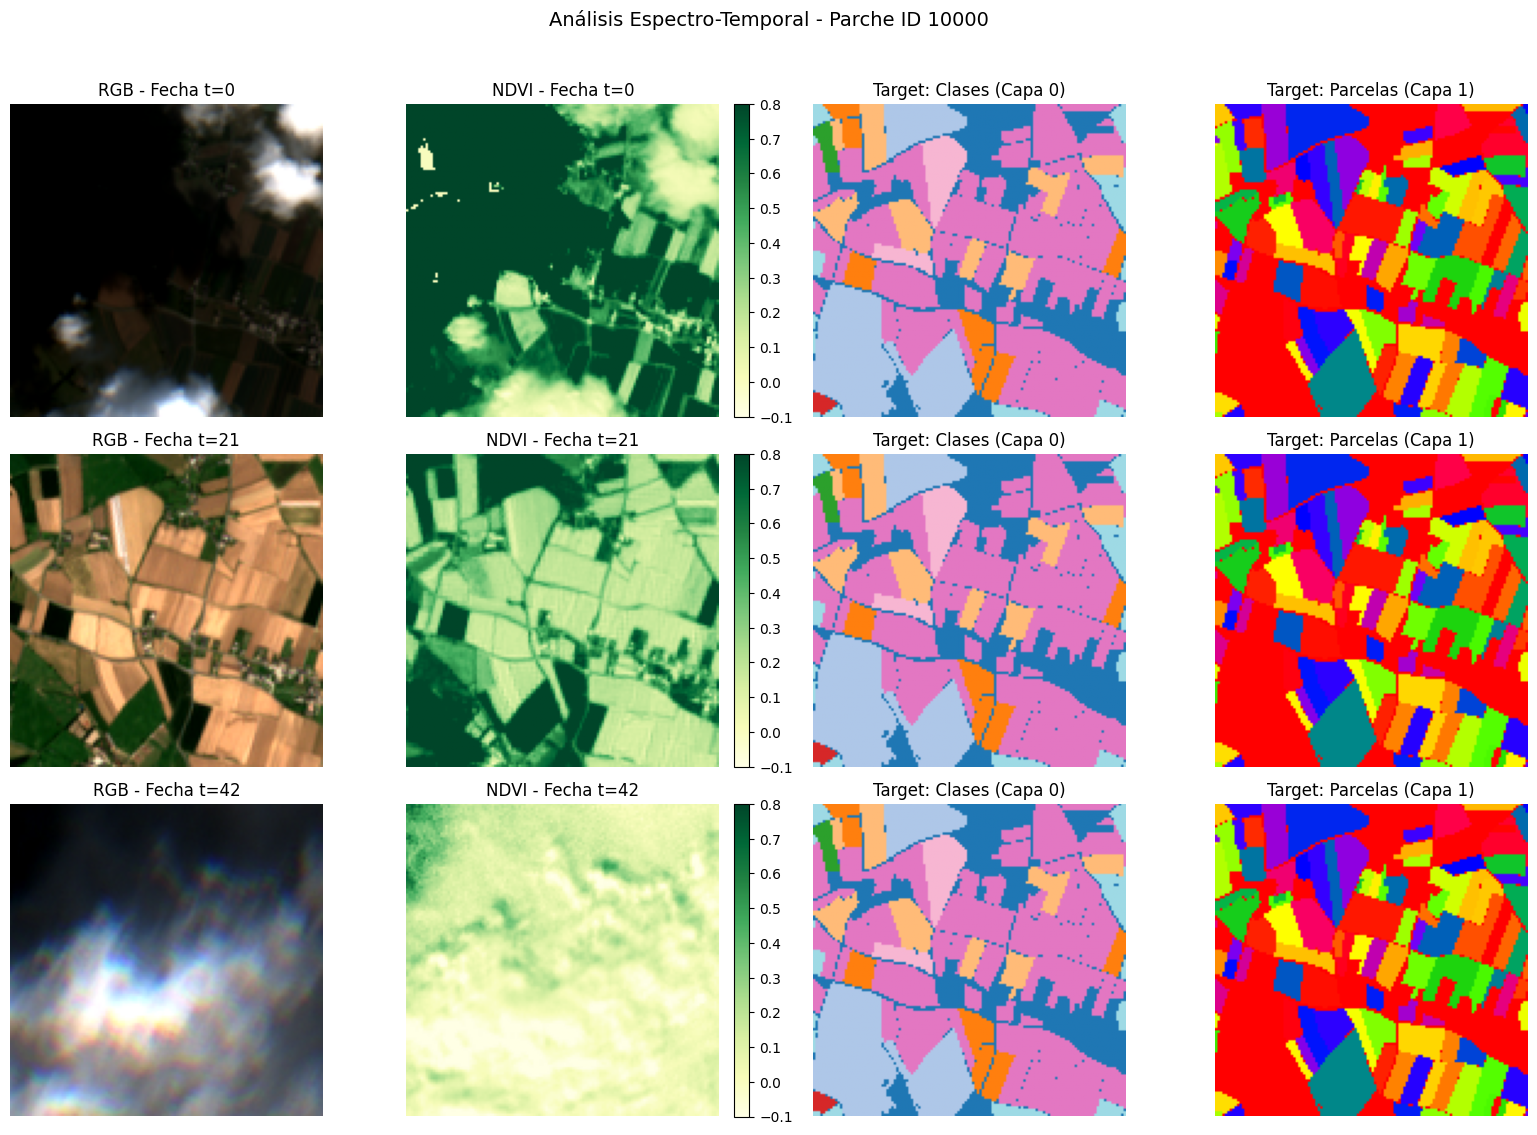

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Separar las 3 capas del TARGET
target_clases = tg_sample[0]     # Capa 0: Clases de cultivo (0 a 19)
target_parcelas = tg_sample[1]   # Capa 1: ID de parcelas/instancias
target_extra = tg_sample[2]      # Capa 2: Bordes/zonas

print("--- Análisis de Capas del TARGET ---")
print("Clases semánticas presentes (Capa 0):", np.unique(target_clases))
print("Número de parcelas independientes (Capa 1):", len(np.unique(target_parcelas)))

# 2. Función de ajuste de contraste para RGB (Percentiles 2% - 98%)
def normalizar_rgb(img_rgb):
    img_clipped = np.clip(img_rgb, 0, None)  # Eliminar valores negativos
    p2, p98 = np.percentile(img_clipped, (2, 98))
    if p98 - p2 == 0:
        return np.zeros_like(img_clipped)
    img_norm = (img_clipped - p2) / (p98 - p2)
    return np.clip(img_norm, 0, 1)

# 3. Selección de 3 fechas clave en la serie temporal (inicio, mitad y fin)
t_indices = [0, s2_sample.shape[0] // 2, s2_sample.shape[0] - 1]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for idx, t in enumerate(t_indices):
    # Selección de bandas Sentinel-2: B04 (Rojo, idx 2), B03 (Verde, idx 1), B02 (Azul, idx 0)
    rgb = s2_sample[t, [2, 1, 0], :, :].transpose(1, 2, 0)
    rgb_norm = normalizar_rgb(rgb)

    # Cálculo de NDVI: (B08 - B04) / (B08 + B04) -> B08 es idx 6 (NIR), B04 es idx 2 (Red)
    b08 = s2_sample[t, 6, :, :].astype(float)
    b04 = s2_sample[t, 2, :, :].astype(float)
    ndvi = (b08 - b04) / (b08 + b04 + 1e-8)
    ndvi = np.clip(ndvi, -1, 1)

    # Columna 1: RGB True Color
    axes[idx, 0].imshow(rgb_norm)
    axes[idx, 0].set_title(f"RGB - Fecha t={t}")
    axes[idx, 0].axis("off")

    # Columna 2: Mapa NDVI
    im_ndvi = axes[idx, 1].imshow(ndvi, cmap="YlGn", vmin=-0.1, vmax=0.8)
    axes[idx, 1].set_title(f"NDVI - Fecha t={t}")
    axes[idx, 1].axis("off")
    fig.colorbar(im_ndvi, ax=axes[idx, 1], fraction=0.046, pad=0.04)

    # Columna 3: Clases Semánticas (Capa 0)
    axes[idx, 2].imshow(target_clases, cmap="tab20")
    axes[idx, 2].set_title("Target: Clases (Capa 0)")
    axes[idx, 2].axis("off")

    # Columna 4: Parcelas Instancias (Capa 1)
    axes[idx, 3].imshow(target_parcelas, cmap="prism")
    axes[idx, 3].set_title("Target: Parcelas (Capa 1)")
    axes[idx, 3].axis("off")

plt.suptitle(f"Análisis Espectro-Temporal - Parche ID {sample_id}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación**

La visualización permite observar que una misma parcela presenta variaciones espectrales a lo largo del tiempo. Estas diferencias se reflejan tanto en la representación RGB como en el NDVI, indicador relacionado con la actividad de la vegetación. Esta variabilidad temporal constituye información relevante para diferenciar cultivos que pueden presentar características espectrales similares en una fecha determinada, pero comportamientos fenológicos distintos a lo largo de su ciclo de crecimiento.

Lo anterior justifica el uso de modelos capaces de considerar simultáneamente las dimensiones espacial y temporal, como TSViT, en lugar de analizar cada adquisición satelital de manera independiente.

# 5. Análisis de Granularidad Espacial

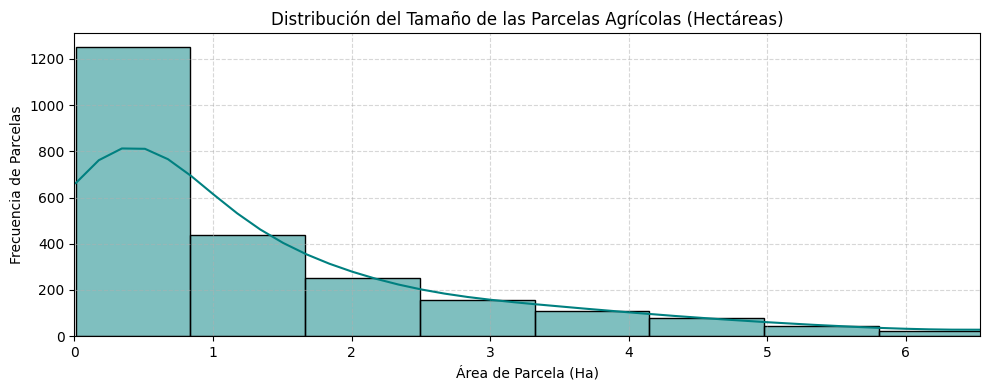

📐 Tamaño mediano de parcela: 0.82 Ha (82 píxeles)
📐 Tamaño máximo detectado: 33.12 Ha


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

areas_pixeles = []

for patch_id in ids_muestra:
    tg = np.load(target_dict[patch_id])
    mapa_parcelas = tg[1] # Capa 1: ID único por parcela

    # Contar píxeles por cada ID de parcela
    ids_unicos, counts = np.unique(mapa_parcelas, return_counts=True)

    # Omitir el fondo (ID 0)
    for p_id, count in zip(ids_unicos, counts):
        if p_id != 0:
            areas_pixeles.append(count)

df_areas = pd.DataFrame({"Pixeles": areas_pixeles})
df_areas["Hectareas"] = (df_areas["Pixeles"] * 100) / 10000  # 1 px = 100m²

plt.figure(figsize=(10, 4))
sns.histplot(df_areas["Hectareas"], bins=40, kde=True, color="teal")
plt.title("Distribución del Tamaño de las Parcelas Agrícolas (Hectáreas)")
plt.xlabel("Área de Parcela (Ha)")
plt.ylabel("Frecuencia de Parcelas")
plt.xlim(0, df_areas["Hectareas"].quantile(0.95)) # Filtrar el 5% superior para mejor escala
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"📐 Tamaño mediano de parcela: {df_areas['Hectareas'].median():.2f} Ha ({df_areas['Pixeles'].median():.0f} píxeles)")
print(f"📐 Tamaño máximo detectado: {df_areas['Hectareas'].max():.2f} Ha")

**Interpretación**

El análisis muestra que las parcelas presentan tamaños heterogéneos, característica esperable en escenarios agrícolas reales. Esta variabilidad implica que el modelo de segmentación deberá ser capaz de reconocer tanto parcelas pequeñas como extensiones agrícolas mayores sin depender exclusivamente de una escala espacial determinada.

Esta observación será especialmente relevante durante la adaptación del modelo a México, donde la distribución de tamaños y geometrías de las parcelas puede diferir de la observada en PASTIS. Por tanto, esta característica deberá compararse posteriormente entre ambos dominios.

# 6. Firmas Fenológicas y Series de Tiempo

⏱️ --- BLOQUE: Análisis Temporal y Firmas Fenológicas ---
📊 Estadísticas de la dimensión temporal (T):
   • Mínimo de fechas registradas: 38
   • Máximo de fechas registradas: 61
   • Promedio de observaciones por parche: 47.1


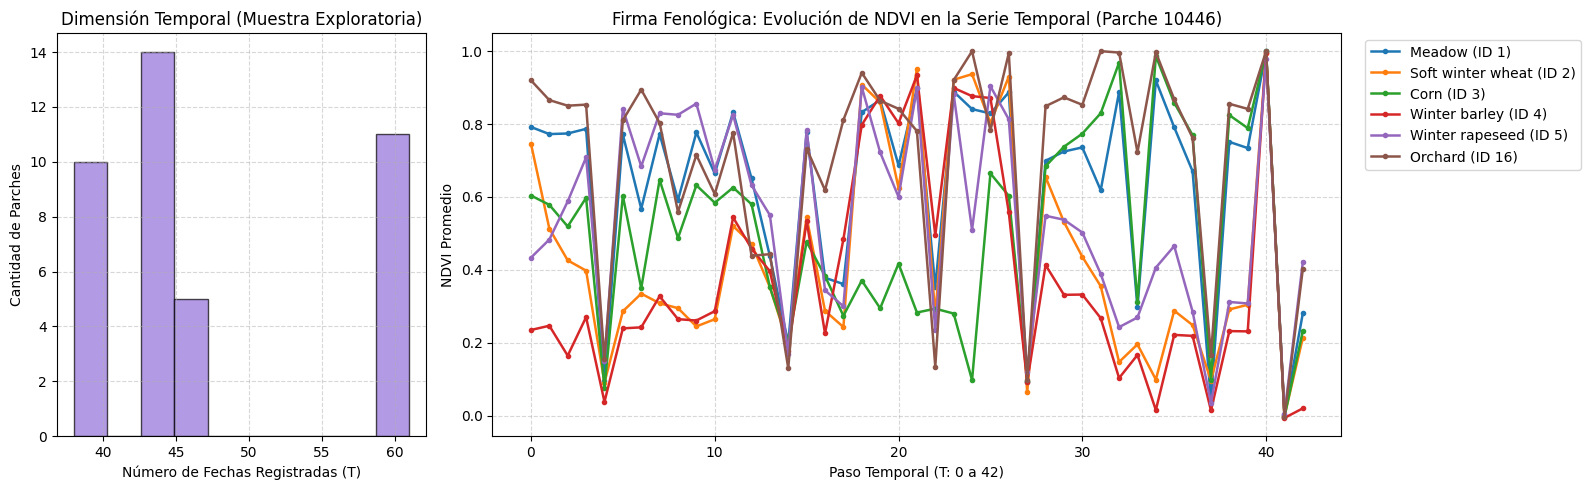

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

print("⏱️ --- BLOQUE: Análisis Temporal y Firmas Fenológicas ---")

# 0. Definición explícita del diccionario de clases de PASTIS
CLASES = {
    0: "Background", 1: "Meadow", 2: "Soft winter wheat", 3: "Corn", 4: "Winter barley",
    5: "Winter rapeseed", 6: "Spring barley", 7: "Sunflower", 8: "Grapevine", 9: "Beet",
    10: "Winter triticale", 11: "Winter durum wheat", 12: "Fruits/veg/flowers",
    13: "Potatoes", 14: "Leguminous fodder", 15: "Soybeans", 16: "Orchard",
    17: "Mixed cereal", 18: "Sorghum", 19: "Void label"
}

# 1. Diagnóstico de la dimensión temporal T en la muestra de parches (Paso C)
secuencias_temporales = []

for patch_id in ids_muestra:
    s2 = np.load(s2_dict[patch_id])
    secuencias_temporales.append(s2.shape[0])

t_min = np.min(secuencias_temporales)
t_max = np.max(secuencias_temporales)
t_mean = np.mean(secuencias_temporales)

print(f"📊 Estadísticas de la dimensión temporal (T):")
print(f"   • Mínimo de fechas registradas: {t_min}")
print(f"   • Máximo de fechas registradas: {t_max}")
print(f"   • Promedio de observaciones por parche: {t_mean:.1f}")

# 2. Extracción de series temporales de NDVI aceleradas por GPU
sample_id = ids_muestra[0]
s2_sample = np.load(s2_dict[sample_id])
tg_sample = np.load(target_dict[sample_id])
target_clases = tg_sample[0]

# Transferir tensores a VRAM (GPU)
s2_gpu = torch.from_numpy(s2_sample).float().to(device)  # Shape: (T, 10, H, W)

# Selección de bandas: B08 (NIR, idx 6) y B04 (Red, idx 2)
b08_gpu = s2_gpu[:, 6, :, :]
b04_gpu = s2_gpu[:, 2, :, :]

# Cálculo vectorial de NDVI
ndvi_stack_gpu = (b08_gpu - b04_gpu) / (b08_gpu + b04_gpu + 1e-8)
ndvi_stack_gpu = torch.clamp(ndvi_stack_gpu, -1.0, 1.0)
ndvi_stack = ndvi_stack_gpu.cpu().numpy()  # Shape: (T, 128, 128)

# 3. Visualización doble: Distribución de T + Curvas Fenológicas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1, 2.3]})

# Subgráfico 1: Consistencia de la dimensión temporal T (Paso C)
ax1.hist(secuencias_temporales, bins=10, color='mediumpurple', edgecolor='black', alpha=0.7)
ax1.set_title("Dimensión Temporal (Muestra Exploratoria)")
ax1.set_xlabel("Número de Fechas Registradas (T)")
ax1.set_ylabel("Cantidad de Parches")
ax1.grid(True, linestyle="--", alpha=0.5)

# Subgráfico 2: Evolución fenológica del NDVI por cultivo etiquetado
clases_presentes = np.unique(target_clases)
for c in clases_presentes:
    if c in [0, 19]:  # Omitir fondo (0) y sin etiqueta (19)
        continue
    mask = (target_clases == c)
    if mask.sum() >= 15:  # Filtrar cultivos con al menos 15 píxeles en el parche
        ndvi_prom = ndvi_stack[:, mask].mean(axis=1)
        nombre = CLASES.get(c, f"Clase {c}")
        ax2.plot(ndvi_prom, marker='o', markersize=3, linewidth=1.8, label=f"{nombre} (ID {c})")

ax2.set_title(f"Firma Fenológica: Evolución de NDVI en la Serie Temporal (Parche {sample_id})")
ax2.set_xlabel("Paso Temporal (T: 0 a 42)")
ax2.set_ylabel("NDVI Promedio")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

,Observaciones_temporales
count,2433.000000
mean,47.357994
std,8.508200
min,38.000000
25%,43.000000
50%,46.000000
75%,61.000000
max,61.000000


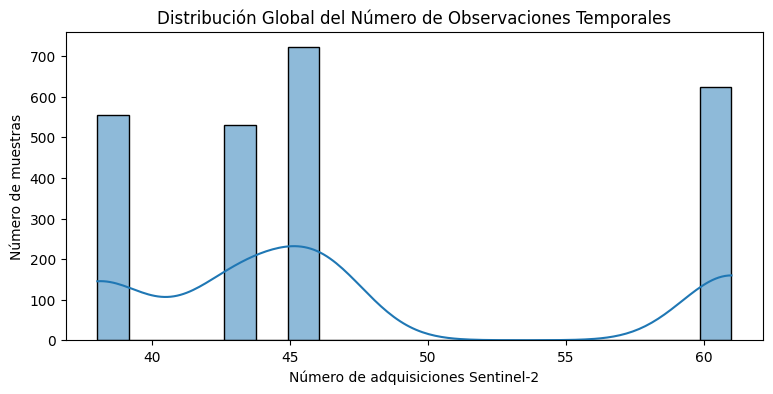

In [ ]:
# Distribución del número de observaciones temporales en todo el dataset
longitudes_temporales = []

for patch_id in ids_comunes:
    s2 = np.load(s2_dict[patch_id], mmap_mode='r')
    longitudes_temporales.append(s2.shape[0])

df_temporal = pd.DataFrame({
    "Observaciones_temporales": longitudes_temporales
})

display(df_temporal.describe())

plt.figure(figsize=(9, 4))
sns.histplot(df_temporal["Observaciones_temporales"], bins=20, kde=True)
plt.title("Distribución Global del Número de Observaciones Temporales")
plt.xlabel("Número de adquisiciones Sentinel-2")
plt.ylabel("Número de muestras")
plt.show()

**Interpretación**

Las series temporales no necesariamente contienen el mismo número de adquisiciones. Esta variabilidad constituye una característica relevante del dataset, ya que el modelo debe manejar secuencias temporales de diferente longitud o aplicar mecanismos de preparación que permitan homogeneizar su representación.

Desde la perspectiva del proyecto, esta característica deberá analizarse nuevamente cuando se incorporen imágenes correspondientes a México, debido a que la disponibilidad temporal de observaciones puede cambiar por factores como cobertura nubosa, frecuencia de adquisición o periodo agrícola analizado.

# 7. Diagnóstico de Desbalance Global de Clases

📊 Procesando 2433 parches para análisis global de clases...
   Procesados 250/2433 parches
   Procesados 500/2433 parches
   Procesados 750/2433 parches
   Procesados 1000/2433 parches
   Procesados 1250/2433 parches
   Procesados 1500/2433 parches
   Procesados 1750/2433 parches
   Procesados 2000/2433 parches
   Procesados 2250/2433 parches
   Procesados 2433/2433 parches

DISTRIBUCIÓN GLOBAL DE CLASES
Parches analizados : 2,433
Píxeles analizados : 39,862,272
Clases presentes   : 20


,ID_Clase,Nombre,Pixeles,Porcentaje
0,0,Background,15907494,39.906140
1,1,Meadow,7289116,18.285751
2,19,Void label,3839780,9.632617
3,3,Corn,3451442,8.658418
4,2,Soft winter wheat,2733960,6.858515
5,8,Grapevine,1108797,2.781570
6,4,Winter barley,810895,2.034242
7,5,Winter rapeseed,705329,1.769415
8,14,Leguminous fodder,635561,1.594392
9,15,Soybeans,420060,1.053778


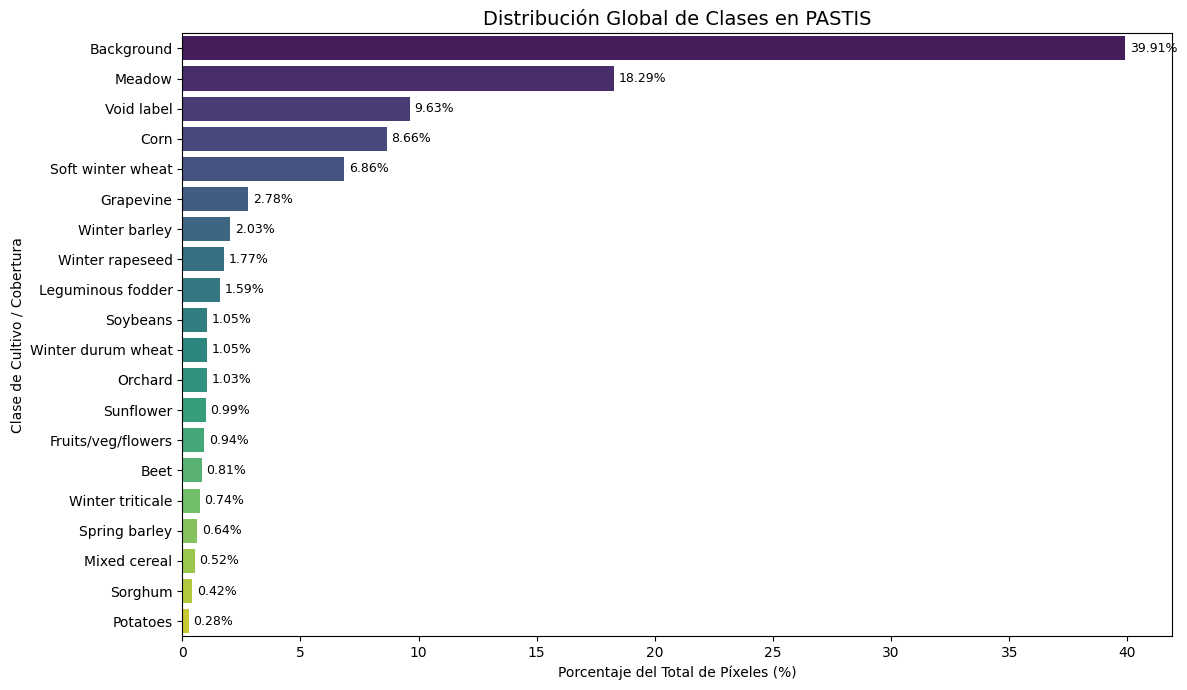

In [ ]:
import pandas as pd
import seaborn as sns

# ============================================================
# 7. DIAGNÓSTICO GLOBAL DE DESBALANCE DE CLASES
# ============================================================

# Contador global para las 20 clases semánticas (0 a 19)
conteo_clases = np.zeros(20, dtype=np.int64)

print(f"📊 Procesando {len(ids_comunes)} parches para análisis global de clases...")

for i, patch_id in enumerate(ids_comunes, start=1):

    # mmap_mode evita cargar innecesariamente todo el archivo en memoria
    tg = np.load(target_dict[patch_id], mmap_mode='r')

    # Capa 0: clases semánticas
    clases_capa = tg[0]

    # Contar píxeles por clase (0 a 19)
    counts = np.bincount(
        clases_capa.ravel().astype(np.int64),
        minlength=20
    )

    conteo_clases += counts[:20]

    # Mostrar avance cada 250 parches
    if i % 250 == 0 or i == len(ids_comunes):
        print(f"   Procesados {i}/{len(ids_comunes)} parches")

# ============================================================
# CREAR DATAFRAME
# ============================================================

df_clases = pd.DataFrame({
    'ID_Clase': list(range(20)),
    'Nombre': [CLASES.get(i, f"Clase {i}") for i in range(20)],
    'Pixeles': conteo_clases
})

total_pixeles = df_clases['Pixeles'].sum()

df_clases['Porcentaje'] = (
    df_clases['Pixeles'] / total_pixeles
) * 100

# Ordenar de mayor a menor frecuencia
df_clases = (
    df_clases
    .sort_values(by='Pixeles', ascending=False)
    .reset_index(drop=True)
)

# ============================================================
# RESUMEN NUMÉRICO
# ============================================================

print("\n" + "=" * 60)
print("DISTRIBUCIÓN GLOBAL DE CLASES")
print("=" * 60)

print(f"Parches analizados : {len(ids_comunes):,}")
print(f"Píxeles analizados : {total_pixeles:,}")
print(f"Clases presentes   : {(df_clases['Pixeles'] > 0).sum()}")

display(df_clases)

# ============================================================
# VISUALIZACIÓN
# ============================================================

plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    data=df_clases,
    x='Porcentaje',
    y='Nombre',
    hue='Nombre',
    legend=False,
    palette='viridis'
)

plt.title(
    "Distribución Global de Clases en PASTIS",
    fontsize=14
)

plt.xlabel("Porcentaje del Total de Píxeles (%)")
plt.ylabel("Clase de Cultivo / Cobertura")

for index, row in df_clases.iterrows():
    if row['Porcentaje'] > 0:
        barplot.text(
            row['Porcentaje'] + 0.2,
            index,
            f"{row['Porcentaje']:.2f}%",
            va='center',
            fontsize=9
        )

plt.tight_layout()
plt.show()

**Interpretación**

La distribución global de los 39,862,272 píxeles analizados evidencia un desbalance importante entre las clases. Background concentra el 39.91% de los píxeles y Meadow el 18.29%, mientras que otras clases agrícolas presentan una representación considerablemente menor; por ejemplo, Potatoes representa únicamente el 0.28% del total. Adicionalmente, el 9.63% corresponde a la etiqueta Void.

Este desbalance es relevante para el entrenamiento, ya que una función de pérdida convencional podría favorecer las clases mayoritarias y producir un desempeño global aparentemente alto aun cuando las clases menos frecuentes sean segmentadas deficientemente.

Por ello, en etapas posteriores deberán considerarse métricas por clase —particularmente IoU, precisión, recall y F1— además de métricas agregadas. También podrá evaluarse el uso de ponderación de clases, funciones de pérdida específicas o estrategias de muestreo si el desbalance afecta el desempeño del modelo.

Esta distribución constituye además una línea base importante para la futura adaptación a México, ya que no debe asumirse que la frecuencia de cultivos observada en PASTIS será representativa del contexto agrícola mexicano.

### 7.1 Cardinalidad de las variables categóricas

Además de analizar la frecuencia de las clases, resulta importante determinar su cardinalidad, es decir, cuántos valores o categorías diferentes aparecen en las variables categóricas asociadas al problema.

En este dataset, la principal variable categórica para la tarea de segmentación semántica corresponde a la clase asignada a cada píxel. Adicionalmente, las anotaciones contienen identificadores de instancia que permiten distinguir las diferentes parcelas presentes en cada muestra.

Este análisis permite diferenciar dos conceptos: el número de categorías semánticas que el modelo debe aprender a predecir y el número de instancias agrícolas individuales presentes en el conjunto de datos.

In [ ]:
# ============================================================
# CARDINALIDAD DE LAS CLASES SEMÁNTICAS
# ============================================================

clases_globales = set()

for patch_id in ids_comunes:
    target = np.load(
        target_dict[patch_id],
        mmap_mode="r"
    )

    # Capa 0: clases semánticas
    clases_globales.update(
        np.unique(target[0]).tolist()
    )

print("CARDINALIDAD DEL DATASET")
print("-" * 50)

print(
    f"Número de clases semánticas observadas: "
    f"{len(clases_globales)}"
)

print(
    f"Clases observadas: "
    f"{sorted(clases_globales)}"
)

CARDINALIDAD DEL DATASET
--------------------------------------------------
Número de clases semánticas observadas: 20
Clases observadas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


,n_instancias
count,2433.000000
mean,61.460748
std,41.138518
min,3.000000
25%,39.000000
50%,54.000000
75%,72.000000
max,588.000000


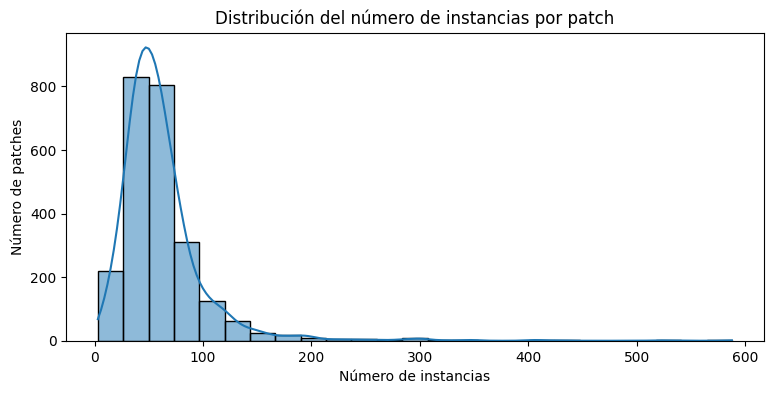

In [ ]:
# Número de instancias por patch
instancias_por_patch = []

for patch_id in ids_comunes:
    target = np.load(target_dict[patch_id], mmap_mode="r")

    ids_instancia = np.unique(target[1])

    # Excluir fondo si el ID 0 representa background
    ids_validos = ids_instancia[ids_instancia != 0]

    instancias_por_patch.append({
        "patch_id": patch_id,
        "n_instancias": len(ids_validos)
    })

df_instancias = pd.DataFrame(instancias_por_patch)

display(df_instancias["n_instancias"].describe())

plt.figure(figsize=(9, 4))
sns.histplot(df_instancias["n_instancias"], bins=25, kde=True)
plt.title("Distribución del número de instancias por patch")
plt.xlabel("Número de instancias")
plt.ylabel("Número de patches")
plt.show()

**Interpretación**

El análisis identificó las 20 categorías semánticas posibles (IDs 0 a 19), incluyendo las categorías Background y Void utilizadas en las anotaciones. Esta cardinalidad representa el conjunto de valores que puede asumir la variable objetivo a nivel de píxel.

Por otra parte, el número de instancias presentes en cada patch muestra una variabilidad espacial considerable. Los 2,433 patches analizados contienen en promedio 61.46 instancias, con una mediana de 54; el número observado varía desde 3 hasta 588 instancias por patch.

Los identificadores de instancia se analizan a nivel de patch y no se interpretan como identificadores globalmente únicos de parcelas en todo PASTIS. Por esta razón, el análisis se centra en la cantidad de instancias presentes en cada escena y no en sumar los IDs diferentes como si representaran parcelas únicas del dataset.

Esta variabilidad será relevante durante la futura adaptación a México, ya que la fragmentación, el tamaño y el número de parcelas por región pueden diferir respecto a PASTIS.

# 8. Firmas Espectrales Promedio

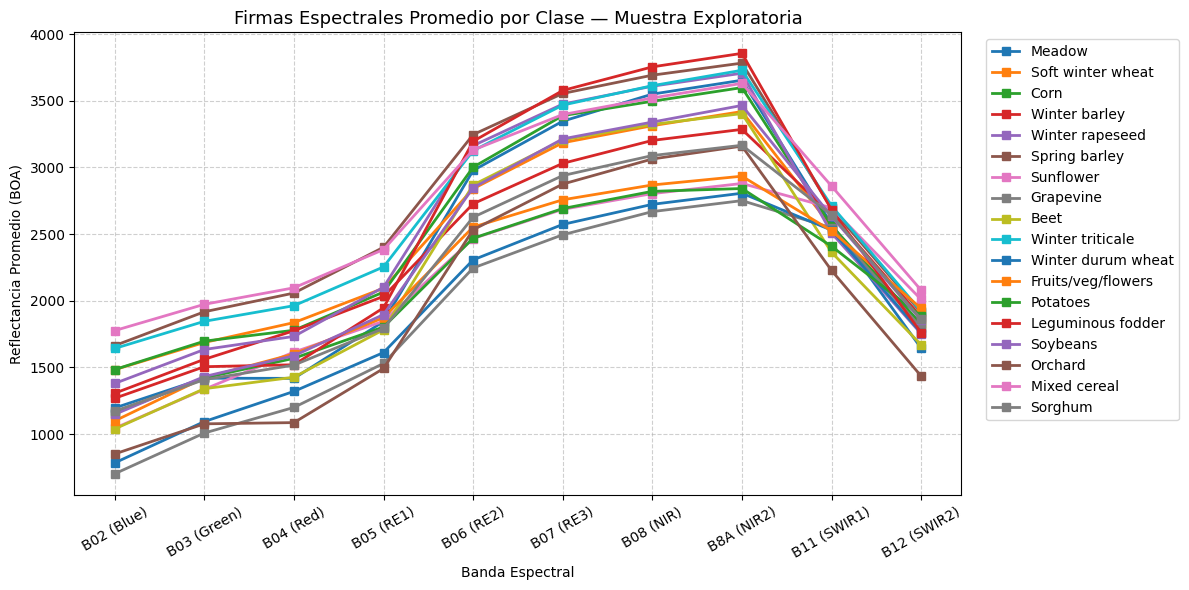

In [ ]:
BANDAS_S2 = ["B02 (Blue)", "B03 (Green)", "B04 (Red)", "B05 (RE1)",
             "B06 (RE2)", "B07 (RE3)", "B08 (NIR)", "B8A (NIR2)",
             "B11 (SWIR1)", "B12 (SWIR2)"]

# Muestreo de píxeles por parche para construir las firmas espectrales
firmas_por_clase = {c: [] for c in range(20)}

for patch_id in ids_muestra[:15]:  # Usamos 15 parches para rapidez
    s2 = np.load(s2_dict[patch_id])  # Shape: (43, 10, 128, 128)
    tg = np.load(target_dict[patch_id])[0]  # Shape: (128, 128)

    # Promedio temporal por parche para reducir dimensión T -> (10, 128, 128)
    s2_mean_time = np.mean(s2, axis=0)

    for c in np.unique(tg):
        if c in [0, 19]: continue  # Omitir fondo y sin etiqueta
        mask = (tg == c)
        if mask.sum() > 0:
            # Promedio espacial para la clase c en este parche -> 10 valores
            valores_bandas = s2_mean_time[:, mask].mean(axis=1)
            firmas_por_clase[c].append(valores_bandas)

# Graficar firmas espectrales
plt.figure(figsize=(12, 6))

for c, valores in firmas_por_clase.items():
    if len(valores) > 0:
        firma_promedio = np.mean(valores, axis=0)
        nombre = CLASES.get(c, f"Clase {c}")
        plt.plot(BANDAS_S2, firma_promedio, marker='s', linewidth=2, label=nombre)

plt.title("Firmas Espectrales Promedio por Clase — Muestra Exploratoria", fontsize=13)
plt.xlabel("Banda Espectral")
plt.ylabel("Reflectancia Promedio (BOA)")
plt.xticks(rotation=30)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretación**

Las firmas espectrales muestran que las clases agrícolas presentan respuestas diferentes entre las bandas visibles, red-edge, infrarrojo cercano y SWIR. Sin embargo, existe también superposición entre algunas clases, lo que indica que una única observación espectral puede no ser suficiente para separarlas completamente.

Esta observación refuerza la importancia de combinar información espectral con la dimensión temporal. Para la futura adaptación a México será necesario verificar si las firmas espectrales de cultivos equivalentes conservan patrones similares o presentan desplazamientos derivados de condiciones climáticas, fenológicas, geográficas o de adquisición.

# 9. Matriz de Correlación Espectral

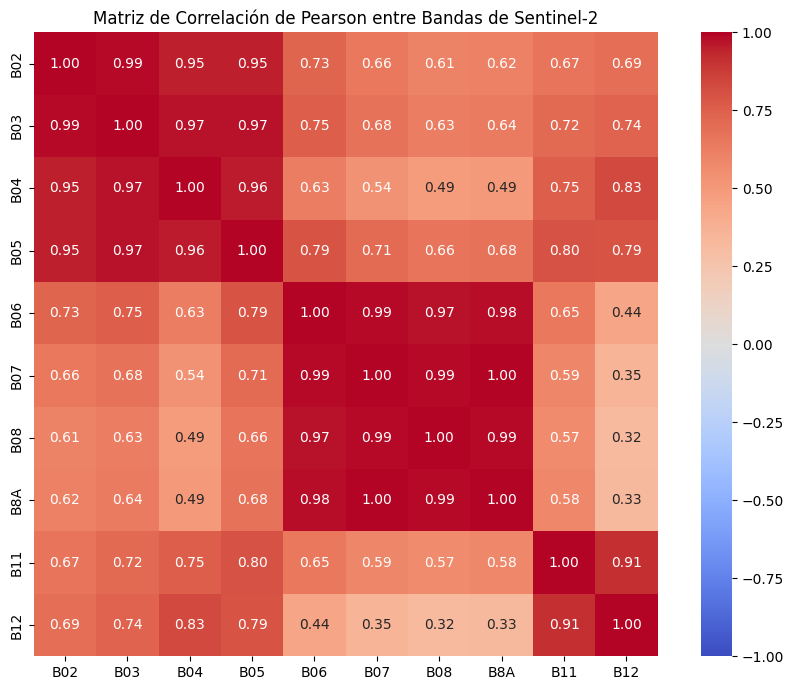

In [ ]:
# ============================================================
# MATRIZ DE CORRELACIÓN ESPECTRAL
# ============================================================

# Generador aleatorio reproducible
rng_corr = np.random.default_rng(42)

# Acumular píxeles aleatorios de la muestra
pixeles_acumulados = []

for patch_id in ids_muestra[:10]:

    # Serie temporal Sentinel-2
    s2 = np.load(
        s2_dict[patch_id]
    )

    # Promedio temporal
    # Shape: (10, 128, 128)
    s2_mean_time = np.mean(
        s2,
        axis=0
    )

    # Reorganizar a matriz:
    # (10, H, W) -> (N_pixeles, 10)
    flat_pixels = (
        s2_mean_time
        .reshape(10, -1)
        .T
    )

    # Tomar una submuestra reproducible
    # de máximo 1000 píxeles por parche
    n_submuestra = min(
        1000,
        flat_pixels.shape[0]
    )

    indices_sub = rng_corr.choice(
        flat_pixels.shape[0],
        size=n_submuestra,
        replace=False
    )

    pixeles_acumulados.append(
        flat_pixels[indices_sub]
    )

# Unir muestras
matriz_datos = np.vstack(
    pixeles_acumulados
)

# Crear DataFrame
df_bandas = pd.DataFrame(
    matriz_datos,
    columns=[
        b.split()[0]
        for b in BANDAS_S2
    ]
)

# Matriz de correlación de Pearson
corr_matrix = df_bandas.corr()

# Visualización
plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "Matriz de Correlación de Pearson entre Bandas de Sentinel-2",
    fontsize=12
)

plt.tight_layout()
plt.show()

**Interpretación**

La matriz de correlación permite identificar relaciones lineales y posibles redundancias entre las bandas espectrales utilizadas como variables de entrada. Debido a que la variable objetivo es categórica —clase semántica por píxel—, una correlación de Pearson directa entre las bandas y la salida no resulta adecuada. Por esta razón, posteriormente se utiliza η² como medida complementaria para estimar la capacidad discriminatoria de cada banda respecto a las clases.

Una correlación elevada entre determinadas bandas no implica automáticamente que deban eliminarse. En arquitecturas profundas como TSViT, el modelo puede aprender combinaciones no lineales y temporales de estas variables. Por ello, cualquier reducción definitiva de bandas deberá validarse experimentalmente.

# 10. Calidad de Datos, Valores Faltantes y Atípicos

En esta sección se analiza explícitamente la calidad de los datos con el objetivo de identificar valores faltantes (NaN), infinitos, valores fuera de los rangos esperados y posibles observaciones atípicas. Es importante distinguir entre un valor estadísticamente extremo y un dato inválido, por lo que no se realizará una eliminación automática antes de caracterizar su frecuencia y distribución.

In [ ]:
print("🔍 Evaluando calidad de los datos...")

# ============================================================
# CALIDAD DE LAS IMÁGENES SENTINEL-2
# ============================================================

resumen_calidad = []

for patch_id in ids_comunes:

    s2 = np.load(
        s2_dict[patch_id],
        mmap_mode='r'
    )

    resumen_calidad.append({
        "ID": patch_id,
        "T": s2.shape[0],
        "NaN": np.isnan(s2).sum(),
        "Inf": np.isinf(s2).sum(),
        "Negativos": (s2 < 0).sum(),
        "Mayores_10000": (s2 > 10000).sum(),
        "Total": s2.size
    })

df_calidad = pd.DataFrame(resumen_calidad)

df_calidad["Pct_Negativos"] = (
    df_calidad["Negativos"]
    / df_calidad["Total"]
    * 100
)

df_calidad["Pct_Mayores_10000"] = (
    df_calidad["Mayores_10000"]
    / df_calidad["Total"]
    * 100
)

print("\n" + "=" * 60)
print("CALIDAD DE LAS IMÁGENES SENTINEL-2")
print("=" * 60)

print(f"Parches analizados: {len(ids_comunes):,}")
print(f"NaN totales: {df_calidad['NaN'].sum():,}")
print(f"Inf totales: {df_calidad['Inf'].sum():,}")
print(f"Valores negativos: {df_calidad['Negativos'].sum():,}")
print(f"Valores > 10000: {df_calidad['Mayores_10000'].sum():,}")

print("\nResumen estadístico:")
display(df_calidad.describe())


# ============================================================
# CALIDAD DE LAS VARIABLES OBJETIVO (TARGET)
# ============================================================

resumen_target = []

for patch_id in ids_comunes:

    target = np.load(
        target_dict[patch_id],
        mmap_mode='r'
    )

    resumen_target.append({
        "ID": patch_id,
        "NaN_TARGET": np.isnan(target).sum(),
        "Inf_TARGET": np.isinf(target).sum()
    })

df_calidad_target = pd.DataFrame(resumen_target)

print("\n" + "=" * 60)
print("CALIDAD DE LAS VARIABLES OBJETIVO (TARGET)")
print("=" * 60)

print(f"NaN totales en TARGET: {df_calidad_target['NaN_TARGET'].sum():,}")
print(f"Inf totales en TARGET: {df_calidad_target['Inf_TARGET'].sum():,}")

🔍 Evaluando calidad de los datos...


**Interpretación**

El análisis global de calidad no identificó valores NaN ni infinitos en las imágenes Sentinel-2 de los 2,433 patches analizados. Tampoco se detectaron valores NaN o infinitos en las variables objetivo (TARGET). Por lo tanto, no se requiere una estrategia de imputación de valores faltantes para estas variables.

Sin embargo, sí se identificaron valores espectrales fuera del intervalo de referencia [0, 10000]. En total se observaron 176,359,287 valores negativos y 77,605,136 valores superiores a 10,000. A nivel de patch, estos representan en promedio aproximadamente 0.87% y 0.43% de los valores, respectivamente.

Estos valores no se eliminan ni se truncan automáticamente, ya que su presencia no implica necesariamente que correspondan a errores. En la siguiente sección se analiza su comportamiento dentro de las distribuciones espectrales para fundamentar cualquier decisión posterior de preprocesamiento.

Por lo tanto, el principal hallazgo de calidad no corresponde a datos faltantes, sino a la presencia de valores extremos que deberán considerarse al definir la estrategia definitiva de normalización y preprocesamiento.

# 11. Estadística Descriptiva y Normalización

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("📊 Calculando estadísticas descriptivas y de normalización por banda...")

# ============================================================
# ACUMULADORES
# ============================================================

# Acumuladores para las 10 bandas
suma_bandas = np.zeros(10, dtype=np.float64)
suma_sq_bandas = np.zeros(10, dtype=np.float64)
total_pixeles = 0

# Muestra utilizada para estadísticos descriptivos e histogramas
muestras_bandas = []

# Generador aleatorio reproducible
rng = np.random.default_rng(42)

# Máximo de puntos espectrales por parche para las visualizaciones
MAX_MUESTRA_POR_PATCH = 10000


# ============================================================
# RECORRER LOS PARCHES DE LA MUESTRA EXPLORATORIA
# ============================================================

for patch_id in ids_muestra:

    # Shape esperado: (T, 10, H, W)
    s2 = np.load(
        s2_dict[patch_id],
        mmap_mode='r'
    ).astype(np.float32)

    # No se aplica clipping en esta etapa.
    # Primero se analiza la distribución original de los datos.

    # (T, C, H, W) -> (N_puntos, 10)
    flat_s2 = (
        s2.transpose(0, 2, 3, 1)
          .reshape(-1, 10)
    )

    # Acumuladores para media y desviación estándar
    suma_bandas += flat_s2.sum(
        axis=0,
        dtype=np.float64
    )

    suma_sq_bandas += np.square(
        flat_s2,
        dtype=np.float64
    ).sum(axis=0)

    total_pixeles += flat_s2.shape[0]

    # Submuestra para estadísticos descriptivos e histogramas
    n_muestra = min(
        MAX_MUESTRA_POR_PATCH,
        flat_s2.shape[0]
    )

    indices = rng.choice(
        flat_s2.shape[0],
        size=n_muestra,
        replace=False
    )

    muestras_bandas.append(
        flat_s2[indices]
    )


# ============================================================
# MEDIA Y DESVIACIÓN ESTÁNDAR DE LA MUESTRA EXPLORATORIA
# ============================================================

medias_muestra = (
    suma_bandas / total_pixeles
)

stds_muestra = np.sqrt(
    (suma_sq_bandas / total_pixeles)
    - (medias_muestra ** 2)
)


# ============================================================
# NOMBRES DE LAS BANDAS
# ============================================================

nombres_bandas = [
    b.split()[0]
    for b in BANDAS_S2
]


# ============================================================
# DATAFRAME PARA EL EDA
# ============================================================

muestra_espectral = np.concatenate(
    muestras_bandas,
    axis=0
)

df_bandas_eda = pd.DataFrame(
    muestra_espectral,
    columns=nombres_bandas
)

print(
    f"\nParches analizados: "
    f"{len(ids_muestra)}"
)

print(
    f"Puntos espectrales utilizados para histogramas: "
    f"{len(df_bandas_eda):,}"
)

print(
    f"Puntos considerados para μ y σ: "
    f"{total_pixeles:,}"
)


# ============================================================
# ESTADÍSTICOS DESCRIPTIVOS
# ============================================================

estadisticos = df_bandas_eda.describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

# Rango intercuartílico
estadisticos["IQR"] = (
    estadisticos["75%"]
    - estadisticos["25%"]
)

# Coeficiente de asimetría
estadisticos["Asimetria"] = (
    df_bandas_eda.skew()
)

print(
    "\n📋 Estadísticos descriptivos por banda:"
)

display(
    estadisticos.round(2)
)


# ============================================================
# ESTADÍSTICAS EXPLORATORIAS DE NORMALIZACIÓN
# ============================================================

stats_normalizacion_eda = {
    "bandas": nombres_bandas,
    "mean": medias_muestra.tolist(),
    "std": stds_muestra.tolist()
}

df_stats = pd.DataFrame({
    "Banda": nombres_bandas,
    "Media (μ)": np.round(
        medias_muestra,
        2
    ),
    "Desv. Est. (σ)": np.round(
        stds_muestra,
        2
    )
})

print(
    "\n✅ Estadísticas exploratorias de normalización:"
)

display(df_stats)


# ============================================================
# HISTOGRAMAS DE LAS 10 BANDAS
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 9)
)

axes = axes.flatten()

for i, banda in enumerate(nombres_bandas):

    datos = (
        df_bandas_eda[banda]
        .dropna()
    )

    sns.histplot(
        datos,
        bins=50,
        kde=True,
        ax=axes[i]
    )

    # Media
    axes[i].axvline(
        datos.mean(),
        linestyle=":",
        linewidth=1.5,
        label="Media"
    )

    # Mediana
    axes[i].axvline(
        datos.median(),
        linestyle="--",
        linewidth=1.5,
        label="Mediana"
    )

    axes[i].set_title(
        f"{banda} | "
        f"Asimetría = {datos.skew():.2f}"
    )

    axes[i].set_xlabel(
        "Valor espectral"
    )

    axes[i].set_ylabel(
        "Frecuencia"
    )

    axes[i].legend(
        fontsize=8
    )

plt.suptitle(
    "Distribución de Valores Espectrales "
    "por Banda Sentinel-2",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# EXPORTAR ESTADÍSTICAS EXPLORATORIAS
# ============================================================

with open(
    "norm_stats_eda.json",
    "w"
) as f:

    json.dump(
        stats_normalizacion_eda,
        f,
        indent=4
    )

print(
    "💾 Estadísticas exploratorias guardadas "
    "en 'norm_stats_eda.json'."
)

**Interpretación**

El análisis descriptivo confirma que las diez bandas Sentinel-2 presentan diferencias importantes tanto en escala como en la forma de sus distribuciones. Las bandas B02, B03, B04 y B05 muestran una asimetría positiva marcada, con coeficientes de 1.46, 1.33, 1.32 y 1.14, respectivamente. En contraste, B11 y B12 presentan asimetría negativa, con valores de −1.32 y −1.70. Las bandas B06, B07, B08 y B8A presentan distribuciones comparativamente más cercanas a la simetría.

Los histogramas, percentiles y diferencias entre media y mediana confirman que no todas las bandas siguen distribuciones equivalentes. También se observan valores extremos tanto negativos como superiores a 10,000, consistentes con el diagnóstico realizado en la sección anterior. Estos resultados justifican analizar cuidadosamente el preprocesamiento en lugar de aplicar un truncamiento automático de los valores.

Las medias y desviaciones estándar calculadas corresponden a la muestra exploratoria reproducible de 40 patches. Por esta razón, el archivo `norm_stats_eda.json` constituye únicamente una referencia exploratoria y no debe utilizarse como las estadísticas definitivas de entrenamiento.

Para el entrenamiento final, los parámetros de normalización deberán calcularse exclusivamente sobre el conjunto de entrenamiento para evitar fuga de información. Asimismo, al adaptar el modelo al dataset mexicano deberá repetirse este análisis para identificar posibles diferencias en las distribuciones espectrales respecto a PASTIS, las cuales podrían constituir evidencia de cambio de dominio (domain shift).

# 12. Sensibilidad Estadística y Separabilidad

In [ ]:
from scipy import stats

print(
    "📊 Evaluando separabilidad de clases "
    "mediante Eta cuadrado (η²)..."
)

# Generador aleatorio reproducible
rng_eta = np.random.default_rng(42)

pixeles_lista = []
labels_lista = []


# ============================================================
# EXTRAER MUESTRA ESPECTRAL Y CLASES
# ============================================================

for patch_id in ids_muestra[:15]:

    # Serie temporal Sentinel-2
    s2 = np.load(
        s2_dict[patch_id]
    )

    # Capa 0 del TARGET:
    # clases semánticas
    tg = np.load(
        target_dict[patch_id]
    )[0]

    # Promedio temporal por banda
    # Shape resultante: (10, H, W)
    #
    # No se aplica clipping para conservar
    # la distribución original de los datos.
    s2_prom = s2.mean(axis=0)

    # Excluir background (0) y void (19)
    mask = (
        (tg > 0)
        & (tg < 19)
    )

    if mask.sum() > 0:

        # Shape: (N_píxeles, 10)
        pixeles = (
            s2_prom[:, mask]
            .T
        )

        labels = tg[mask]

        # Muestreo máximo de 500 píxeles
        # por parche para controlar tamaño
        if pixeles.shape[0] > 500:

            idx = rng_eta.choice(
                pixeles.shape[0],
                size=500,
                replace=False
            )

            pixeles = pixeles[idx]
            labels = labels[idx]

        pixeles_lista.append(
            pixeles
        )

        labels_lista.append(
            labels
        )


# ============================================================
# UNIR LAS MUESTRAS
# ============================================================

X_eval = np.vstack(
    pixeles_lista
)

y_eval = np.concatenate(
    labels_lista
)

print(
    f"Píxeles utilizados en el análisis: "
    f"{len(y_eval):,}"
)

print(
    f"Clases representadas: "
    f"{len(np.unique(y_eval))}"
)


# ============================================================
# CALCULAR ETA CUADRADO POR BANDA
# ============================================================

eta_cuadrado = []

for b in range(10):

    valores_banda = X_eval[:, b]

    grupos = [
        valores_banda[y_eval == c]
        for c in np.unique(y_eval)
    ]

    # ANOVA de una vía
    f_stat, p_val = stats.f_oneway(
        *grupos
    )

    # Suma total de cuadrados
    media_general = np.mean(
        valores_banda
    )

    ss_total = np.sum(
        (
            valores_banda
            - media_general
        ) ** 2
    )

    # Suma de cuadrados entre grupos
    ss_between = sum(
        len(g)
        * (
            np.mean(g)
            - media_general
        ) ** 2
        for g in grupos
    )

    # Eta cuadrado
    eta_sq = (
        ss_between
        / ss_total
    )

    eta_cuadrado.append(
        eta_sq
    )


# ============================================================
# DATAFRAME DE RESULTADOS
# ============================================================

df_eta = pd.DataFrame({
    "Banda": [
        b.split()[0]
        for b in BANDAS_S2
    ],
    "Eta_Cuadrado (η²)": eta_cuadrado
})

df_eta = df_eta.sort_values(
    by="Eta_Cuadrado (η²)",
    ascending=False
)

print(
    "\n📋 Capacidad discriminatoria por banda:"
)

display(
    df_eta.round(4)
)


# ============================================================
# VISUALIZACIÓN
# ============================================================

plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=df_eta,
    x="Banda",
    y="Eta_Cuadrado (η²)",
    hue="Banda",
    legend=False,
    palette="rocket"
)

plt.axhline(
    0.14,
    linestyle="--",
    label="Referencia η² = 0.14"
)

plt.title(
    "Capacidad Discriminatoria de Cada Banda "
    "Frente a las Clases de Cultivo"
)

plt.xlabel(
    "Banda Sentinel-2"
)

plt.ylabel(
    "Eta cuadrado (η²)"
)

plt.legend()

plt.tight_layout()
plt.show()

**Interpretación**

El análisis de separabilidad mediante η² se realizó sobre una muestra de 7,500 píxeles correspondientes a 18 clases de cultivo. Los resultados muestran diferencias claras en la capacidad discriminatoria individual de las bandas.

B8A presentó el mayor valor de η² (0.3547), seguida por B08 (0.3395), B07 (0.3265) y B06 (0.2889). En contraste, B11 presentó el menor valor (0.0711). Estos resultados sugieren que, dentro de la muestra analizada, las bandas del infrarrojo cercano y red-edge contienen información particularmente relevante para diferenciar las clases.

Sin embargo, una menor capacidad discriminatoria individual no implica que una banda deba eliminarse. TSViT puede aprovechar interacciones espectrales, espaciales y temporales que no son capturadas por una evaluación univariada. Por ello, estos resultados se consideran evidencia exploratoria para orientar futuros experimentos de selección de características o ablación, y no como un criterio automático de eliminación de bandas.

# 13. Reducción de Dimensionalidad

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Normalización de la muestra seleccionada
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_eval)

# Ajuste de PCA para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var_explicada = pca.explained_variance_ratio_ * 100

print(f"📈 Varianza acumulada explicada por PC1 y PC2: {var_explicada.sum():.2f}%")

df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Clase_ID': y_eval,
    'Cultivo': [CLASES.get(c, f"Clase {c}") for c in y_eval]
})

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='Cultivo',
    palette='tab20', alpha=0.7, s=25
)
plt.title(f"Proyección PCA de Muestras Espectrales (Varianza explicada: {var_explicada.sum():.1f}%)")
plt.xlabel(f"Componente Principal 1 ({var_explicada[0]:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({var_explicada[1]:.1f}%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretación**

El análisis de componentes principales (PCA) muestra que las dos primeras componentes explican conjuntamente el 92.56% de la variabilidad presente en la muestra espectral analizada. Esto indica que existe una redundancia considerable entre las diez bandas y que una parte importante de su variabilidad puede representarse en un espacio de menor dimensión.

La proyección bidimensional permite además explorar visualmente el grado de superposición o separación entre las clases de cultivo. Sin embargo, esta representación debe interpretarse con cautela, ya que PCA maximiza la varianza global de los datos y no específicamente la separación entre clases.

Por esta razón, el resultado no implica que las diez bandas deban sustituirse automáticamente por dos componentes principales durante el entrenamiento de TSViT. La reducción de dimensionalidad puede eliminar información discriminatoria relevante y, además, el modelo aprovecha relaciones espectrales y temporales que PCA no representa explícitamente.

El resultado se considera, por tanto, evidencia de redundancia espectral y una base para futuros experimentos de reducción de dimensionalidad o ablación, los cuales deberán compararse directamente en términos del desempeño de segmentación.

# 14. Conclusiones del EDA e Implicaciones para el Proyecto

El análisis exploratorio permitió caracterizar PASTIS como un conjunto de datos de alta dimensionalidad que integra información espacial, espectral y temporal. Las muestras Sentinel-2 contienen diez bandas espectrales y un número variable de observaciones temporales, mientras que las anotaciones permiten abordar una tarea de segmentación semántica multiclase y estudiar adicionalmente la estructura espacial de las parcelas agrícolas.

El análisis de la variable objetivo mostró una distribución desigual entre las clases, aspecto que deberá considerarse durante el entrenamiento y la evaluación del modelo. En particular, será importante complementar las métricas globales con métricas por clase, como IoU, precisión, recall y F1, para evitar que el desempeño sobre las clases mayoritarias oculte dificultades en aquellas con menor representación.

Las firmas espectrales y fenológicas muestran que los cultivos presentan diferencias tanto en su respuesta espectral como en su evolución temporal. La matriz de correlación y el análisis mediante PCA permiten explorar la redundancia existente entre determinadas bandas, mientras que η² proporciona una medida de su capacidad discriminatoria individual respecto a las clases. Sin embargo, estos resultados no justifican por sí solos la eliminación de variables, ya que arquitecturas como TSViT pueden aprovechar relaciones no lineales, espaciales y temporales que estos análisis individuales no capturan completamente.

El análisis de calidad no identificó valores NaN ni infinitos en las imágenes Sentinel-2 ni en las variables objetivo, por lo que no se requiere una estrategia de imputación para estos datos. Sin embargo, se identificaron valores espectrales negativos y superiores a 10,000, cuya presencia fue posteriormente considerada dentro del análisis de las distribuciones. Asimismo, el análisis descriptivo mostró diferencias de escala, dispersión y asimetría entre las bandas. Las estadísticas de normalización calculadas durante este EDA se consideran exploratorias; los parámetros definitivos deberán obtenerse exclusivamente a partir del conjunto de entrenamiento para evitar fuga de información.

Finalmente, PASTIS constituye el conjunto de datos de referencia para comprender y validar el pipeline de segmentación antes de su adaptación al contexto mexicano. Los resultados obtenidos en este EDA establecen una línea base para comparar posteriormente la distribución de clases, tamaños de parcela, firmas espectrales, temporalidad y estadísticas de las bandas con el conjunto de datos correspondiente a México. Esta comparación permitirá identificar posibles cambios de dominio (domain shift) y orientar las decisiones de preprocesamiento, adaptación y posterior entrenamiento o ajuste del modelo.